# Polynomials
Just like we saw in the most recent assignment, polynomials can be represented by their coefficients. `numpy.polynomial` implements these and most of the operations that one may way to apply to polynomials.

In [1]:
import numpy as np
from numpy.polynomial import Polynomial

In [2]:
# Create a polynomial from its coefficients
P = Polynomial([1,2,3,4])
print(P)
type(P)

1.0 + 2.0·x + 3.0·x² + 4.0·x³


numpy.polynomial.polynomial.Polynomial

In [3]:
# Polynomials behave like functions in that they can be evaluated
print(f"P(0) = {P(0)}")
print(f"P(1) = {P(1)}")

P(0) = 1.0
P(1) = 10.0


In [4]:
# all agrebraic operations are implemented

Q = Polynomial([3,2,0,3])
print('P+Q:  ', P+Q)
print('P*Q:  ', P*Q)
print('P**2: ', P**2)

P+Q:   4.0 + 4.0·x + 3.0·x² + 7.0·x³
P*Q:   3.0 + 8.0·x + 13.0·x² + 21.0·x³ + 14.0·x⁴ + 9.0·x⁵ + 12.0·x⁶
P**2:  1.0 + 4.0·x + 10.0·x² + 20.0·x³ + 25.0·x⁴ + 24.0·x⁵ + 16.0·x⁶


In [5]:
# We can also recover the copefficients from a polynomial
R = P**2
print(f"R.coef {R.coef}, {type(R.coef)}")

R.coef [ 1.  4. 10. 20. 25. 24. 16.], <class 'numpy.ndarray'>


In [6]:
# derivatives and integrals also are implemented
Q = P.deriv()
print("P': ", Q)
R = P.integ()
print("int P: ", R)

P':  2.0 + 6.0·x + 12.0·x²
int P:  0.0 + 1.0·x + 1.0·x² + 1.0·x³ + 1.0·x⁴


### Application: Lagrange interpolation:
Given $(x_0, x_1, x_2)$ pairwise distinct and $(y_0, y_1, y_2)$, find $P\in\mathbb{P}^2$ such that $P(x_i) = y_i$ for $y = 0, 1, 2$.

* The hard way: write $P(x) = a_0 + a_1x + a_2 x^2$, substitute $P(x_i) = y_i$ and solve a system of three equations with three unknowns.
* The easy way: build three polynomials of degree 2 $\varphi_0, \varphi_1, \varphi_2$ such that $\varphi_i(x_j) = \delta_{i,j}$, and notice that $P(x) = y_0 \varphi_0(x) + y_1 \varphi_1(x) + y_2 \varphi_2(x)$. Construct the $\varphi_i$ from their roots, then normalize them.

In [7]:
P = Polynomial.fromroots([-1,0,1])
print(P)
print(P(-1), P(0), P(1))

0.0 - 1.0·x + 0.0·x² + 1.0·x³
0.0 0.0 0.0


In [11]:
def LagrangeInterpolation(X, Y):
    # construct phi_0, phi_1, phi_2
    phi_0 = np.polynomial.Polynomial.fromroots([X[1], X[2]])
    phi_1 = Polynomial.fromroots([X[0], X[2]])
    phi_2 = Polynomial.fromroots([X[0], X[1]])
    phi_0 = phi_0 / phi_0(X[0])
    phi_1 = phi_1 / phi_1(X[1])
    phi_2 = phi_2 / phi_2(X[2])
    return Y[0] * phi_0 + Y[1] * phi_1 + Y[2] * phi_2

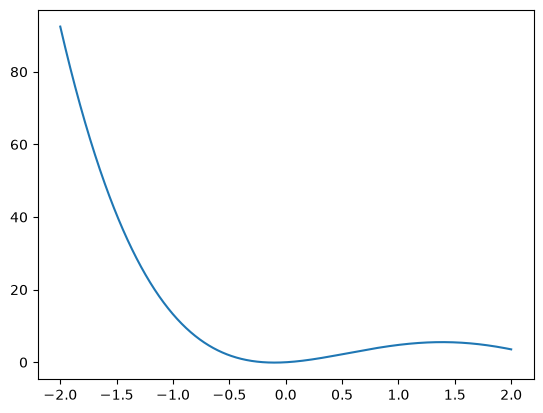

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def q(x):
    return 1.776*x + 8*x**2-6*x**3 + x**4
x = np.linspace(-2,2,1000)
plt.plot(x,q(x))
plt.show()

In [9]:
X = [1,2,3]
Y = [-1, 0, 2]

In [12]:
Q = LagrangeInterpolation(X,Y)
print(Q)
print(Q(X))

-1.0 - 0.5·x + 0.5·x²
[-1.  0.  2.]


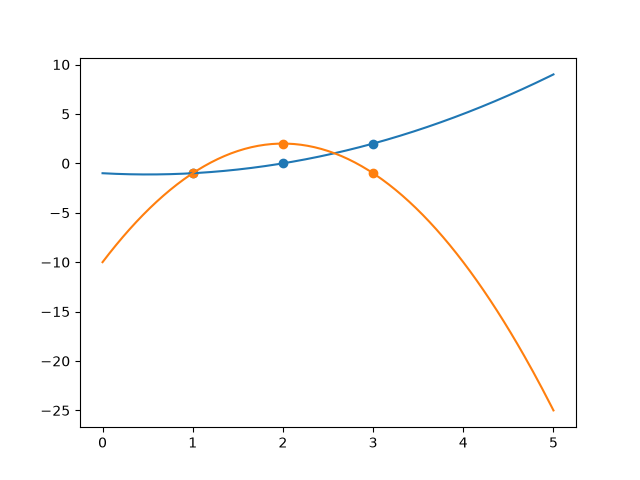

In [13]:
import matplotlib.pyplot as plt
%matplotlib widget
fig, ax = plt.subplots()
X0 = np.linspace(0, 5, 201)

X = [1,2,3]
Y = [-1, 0, 2]
ax.plot(X0,Q(X0))
ax.scatter(X,Y)

Y = [-1,2,-1]
ax.plot(X0,LagrangeInterpolation(X,Y)(X0))
ax.scatter(X,Y)


### Polynomial fit
Given $n$ pairs $(x_i,y_i)$, find the "best" fit by a polynomial $P$ of degree $p$. 

P_0 =  0.3600414
P_1 =  -0.16406784 + 1.61997171·(-0.44950416 + 1.63214032x)
P_2 =  -0.5457905 + 1.6754033·(-0.44950416 + 1.63214032x) +
0.50170906·(-0.44950416 + 1.63214032x)²
P_3 =  -0.36845607 + 1.32061634·(-0.44950416 + 1.63214032x) +
0.3322642·(-0.44950416 + 1.63214032x)² +
0.36324383·(-0.44950416 + 1.63214032x)³
P_4 =  -0.24703367 + 0.91476505·(-0.44950416 + 1.63214032x) +
0.52445372·(-0.44950416 + 1.63214032x)² +
0.76909512·(-0.44950416 + 1.63214032x)³ -
0.31361191·(-0.44950416 + 1.63214032x)⁴


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1499: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


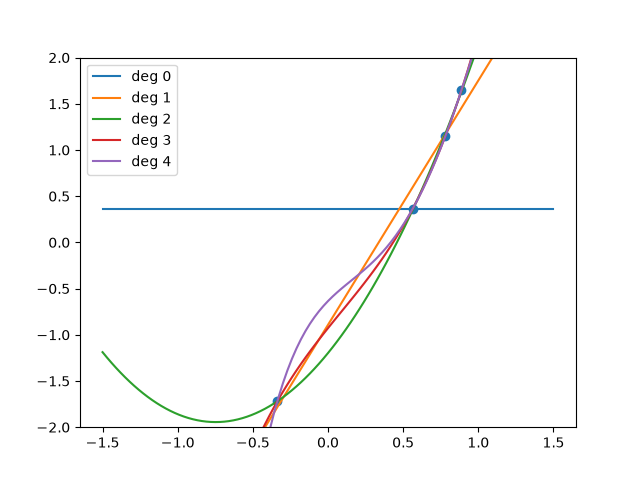

In [14]:
n = 4
sigma = 0.25
X = np.random.uniform(low = -1, high = 1, size = n)
noise = np.random.uniform(low = -1, high = 1, size = n)
def f(x):
    return x**2 + 2*x - 1
Y = f(X) + sigma * noise

fig, ax = plt.subplots()
ax.scatter(X,Y)
XX = np.linspace(-1.5, 1.5, 101)
for d in range(5):
    P = Polynomial.fit(X,Y, deg = d)
    print(f'P_{d} = ', P)
    ax.plot(XX, P(XX), label = f'deg {d}')
    ax.set_ylim((-2,2))
ax.legend()

In [15]:
dir(P)

['__abstractmethods__',
 '__add__',
 '__array_ufunc__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rfloordiv__',
 '__rmod__',
 '__rmul__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_abc_impl',
 '_add',
 '_der',
 '_div',
 '_fit',
 '_format_term',
 '_fromroots',
 '_generate_string',
 '_get_coefficients',
 '_int',
 '_line',
 '_mul',
 '_pow',
 '_repr_latex_',
 '_repr_latex_scalar',
 '_repr_latex_ter

In [ ]:
help(P.domain)